# Simple Segmentation — train and evaluate on U-DIADS-TL

Train the restored `simple_segmentation` model on one U-DIADS-TL subset (`Latin14396`, `Latin2`, or `Syr341`), then evaluate the best checkpoint on the test split with binary-mask metrics and preview the exported overlays.

This notebook uses the current `train.py` and `evaluate.py` entry points directly. It writes checkpoints under `80_models/segmentation/simple_segmentation` and evaluation artifacts under `99_evaluation/simple_segmentation`.

## 1  Select subset and model

In [16]:
from pathlib import Path

import yaml

candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent, Path('/home/artur/Thesis/fsl-tl-manuscripts')]
REPO_ROOT = next((path for path in candidates if (path / '50_modelling' / 'simple_segmentation').exists()), None)
assert REPO_ROOT is not None, 'Could not locate the repository root'

SIMPLE_SEG_DIR = REPO_ROOT / '50_modelling' / 'simple_segmentation'
AVAILABLE_SUBSETS = ['Latin14396', 'Latin2', 'Syr341']
BACKBONE_OPTIONS = {'dinov2': 'dinov2_simple_u_diads', 'resnet34': 'resnet_simple_u_diads'}

SUBSET = 'Latin14396'          # 'Latin14396' | 'Latin2' | 'Syr341'
BACKBONE = 'dinov2'            # 'dinov2' | 'resnet34'
K_SHOT = 3
SELECTION_METHOD = 'grayscale_variance'
THRESHOLD = 0.5
EPOCHS_OVERRIDE = None         # set an integer to override the YAML
BATCH_SIZE_OVERRIDE = None     # set an integer to override the YAML
NUM_WORKERS_OVERRIDE = None    # set an integer to override the YAML

assert SUBSET in AVAILABLE_SUBSETS
assert BACKBONE in BACKBONE_OPTIONS

BASE_CONFIG = SIMPLE_SEG_DIR / 'configs' / f"{BACKBONE_OPTIONS[BACKBONE]}.yaml"
ACTIVE_CONFIG = SIMPLE_SEG_DIR / 'configs' / f"active_u_diads_{BACKBONE}_simple.yaml"

with BASE_CONFIG.open() as handle:
    cfg = yaml.safe_load(handle)

cfg['data']['manuscript'] = SUBSET
cfg['data']['k_shot'] = K_SHOT
cfg['data']['selection_method'] = SELECTION_METHOD
if EPOCHS_OVERRIDE is not None:
    cfg['training']['epochs'] = int(EPOCHS_OVERRIDE)
if BATCH_SIZE_OVERRIDE is not None:
    cfg['training']['batch_size'] = int(BATCH_SIZE_OVERRIDE)
if NUM_WORKERS_OVERRIDE is not None:
    cfg['data']['num_workers'] = int(NUM_WORKERS_OVERRIDE)

with ACTIVE_CONFIG.open('w', encoding='utf-8') as handle:
    yaml.safe_dump(cfg, handle, sort_keys=False)

CONFIG_STEM = ACTIVE_CONFIG.stem
RUN_NAME = f"simple_segmentation_u_diads_{SUBSET}_{CONFIG_STEM}_k{K_SHOT}"
CHECKPOINT_DIR = REPO_ROOT / '80_models' / 'segmentation' / 'simple_segmentation' / RUN_NAME
BEST_CHECKPOINT = CHECKPOINT_DIR / 'best.pth'
FINAL_CHECKPOINT = CHECKPOINT_DIR / 'final.pth'
EVAL_DIR = REPO_ROOT / '99_evaluation' / 'simple_segmentation' / f"simple_segmentation_u_diads_{SUBSET}_{CONFIG_STEM}_best_test"

print('repo root      :', REPO_ROOT)
print('simple seg dir :', SIMPLE_SEG_DIR)
print('base config    :', BASE_CONFIG)
print('active config  :', ACTIVE_CONFIG)
print('checkpoint dir :', CHECKPOINT_DIR)
print('evaluation dir :', EVAL_DIR)

repo root      : /home/artur/Thesis/fsl-tl-manuscripts
simple seg dir : /home/artur/Thesis/fsl-tl-manuscripts/50_modelling/simple_segmentation
base config    : /home/artur/Thesis/fsl-tl-manuscripts/50_modelling/simple_segmentation/configs/dinov2_simple_u_diads.yaml
active config  : /home/artur/Thesis/fsl-tl-manuscripts/50_modelling/simple_segmentation/configs/active_u_diads_dinov2_simple.yaml
checkpoint dir : /home/artur/Thesis/fsl-tl-manuscripts/80_models/segmentation/simple_segmentation/simple_segmentation_u_diads_Latin14396_active_u_diads_dinov2_simple_k3
evaluation dir : /home/artur/Thesis/fsl-tl-manuscripts/99_evaluation/simple_segmentation/simple_segmentation_u_diads_Latin14396_active_u_diads_dinov2_simple_best_test


## 2  Install Python dependencies

If you are already using the project virtual environment, this cell should be quick. The first DINOv2 run may still download pretrained backbone weights.

In [17]:
%pip install -q opencv-python pyyaml tqdm pandas matplotlib scikit-image segmentation-models-pytorch timm

Note: you may need to restart the kernel to use updated packages.


## 3  Train the model

This launches `train.py` with the generated active config. The training script handles k-shot selection, writes checkpoints to `80_models`, and stores visualisation panels inside the run directory.

In [18]:
import subprocess
import sys

# train_cmd = [
#     sys.executable,
#     'train.py',
#     '--config',
#     str(ACTIVE_CONFIG),
# ]

# print('running:', ' '.join(train_cmd))
# subprocess.run(train_cmd, cwd=SIMPLE_SEG_DIR, check=True)

## 4  Inspect the saved checkpoint

In [19]:
import random

import cv2
import matplotlib.pyplot as plt
import torch

BEST_CHECKPOINT = "/home/artur/Thesis/fsl-tl-manuscripts/80_models/segmentation/simple_segmentation/simple_segmentation_u_diads_Latin14396_active_u_diads_dinov2_simple_k1/best.pth"

# assert BEST_CHECKPOINT.exists(), f'missing best checkpoint: {BEST_CHECKPOINT}'
checkpoint = torch.load(BEST_CHECKPOINT, map_location='cpu')
print('best checkpoint :', BEST_CHECKPOINT)
print('best epoch      :', checkpoint.get('epoch'))
print('best val_iou    :', checkpoint.get('val_iou'))

vis_dir = CHECKPOINT_DIR / 'visualisations'
vis_paths = sorted(vis_dir.glob('*.png'))
print('visualisations  :', len(vis_paths))

if vis_paths:
    vis_path = random.choice(vis_paths)
    image = cv2.cvtColor(cv2.imread(str(vis_path)), cv2.COLOR_BGR2RGB)
    print('previewing:', vis_path.name)
    plt.figure(figsize=(16, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

best checkpoint : /home/artur/Thesis/fsl-tl-manuscripts/80_models/segmentation/simple_segmentation/simple_segmentation_u_diads_Latin14396_active_u_diads_dinov2_simple_k1/best.pth
best epoch      : 1
best val_iou    : 0.3847401012278911
visualisations  : 0


## 5  Evaluate on the test split

For U-DIADS this runs mask-space evaluation only. The script writes predicted masks, probability maps, overlays, and per-image plus summary CSV files under `99_evaluation/simple_segmentation`.

In [20]:
# assert BEST_CHECKPOINT.exists(), f'missing best checkpoint: {BEST_CHECKPOINT}'

eval_cmd = [
    sys.executable,
    'evaluate.py',
    '--config',
    str(ACTIVE_CONFIG),
    '--checkpoint',
    str(BEST_CHECKPOINT),
    '--split',
    'test',
    '--threshold',
    str(THRESHOLD),
]

print('running:', ' '.join(eval_cmd))
subprocess.run(eval_cmd, cwd=SIMPLE_SEG_DIR, check=True)

running: /home/artur/Thesis/fsl-tl-manuscripts/.venv/bin/python evaluate.py --config /home/artur/Thesis/fsl-tl-manuscripts/50_modelling/simple_segmentation/configs/active_u_diads_dinov2_simple.yaml --checkpoint /home/artur/Thesis/fsl-tl-manuscripts/80_models/segmentation/simple_segmentation/simple_segmentation_u_diads_Latin14396_active_u_diads_dinov2_simple_k1/best.pth --split test --threshold 0.5


Using cache found in /home/artur/.cache/torch/hub/facebookresearch_dinov2_main
/home/artur/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/artur/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/artur/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Loaded checkpoint from /home/artur/Thesis/fsl-tl-manuscripts/80_models/segmentation/simple_segmentation/simple_segmentation_u_diads_Latin14396_active_u_diads_dinov2_simple_k1/best.pth (epoch 1, val_iou=0.3847401012278911)


Inference [u_diads]: 100%|██████████| 15/15 [00:24<00:00,  1.66s/it]



=== U-DIADS Mask Evaluation Results ===
  IoU: 0.4714
  Precision: 0.4911
  Recall: 0.9225
  F1: 0.6405
  Dice: 0.6405
  Output dir: /home/artur/Thesis/fsl-tl-manuscripts/99_evaluation/simple_segmentation/simple_segmentation_u_diads_Latin14396_active_u_diads_dinov2_simple_best_test


CompletedProcess(args=['/home/artur/Thesis/fsl-tl-manuscripts/.venv/bin/python', 'evaluate.py', '--config', '/home/artur/Thesis/fsl-tl-manuscripts/50_modelling/simple_segmentation/configs/active_u_diads_dinov2_simple.yaml', '--checkpoint', '/home/artur/Thesis/fsl-tl-manuscripts/80_models/segmentation/simple_segmentation/simple_segmentation_u_diads_Latin14396_active_u_diads_dinov2_simple_k1/best.pth', '--split', 'test', '--threshold', '0.5'], returncode=0)

## 6  Review evaluation metrics and overlays

,IoU,Precision,Recall,F1,Dice
0,0.471445,0.491059,0.922543,0.640508,0.640508


,image,IoU,Precision,Recall,F1,Dice
8,136.jpg,0.413685,0.424337,0.942790,0.585257,0.585257
10,251.jpg,0.454802,0.473807,0.918952,0.625242,0.625242
9,223.jpg,0.455380,0.477747,0.906777,0.625789,0.625789
14,276.jpg,0.462005,0.484992,0.906956,0.632015,0.632015
12,264.jpg,0.462549,0.497312,0.868717,0.632525,0.632525


previewing: 223.png


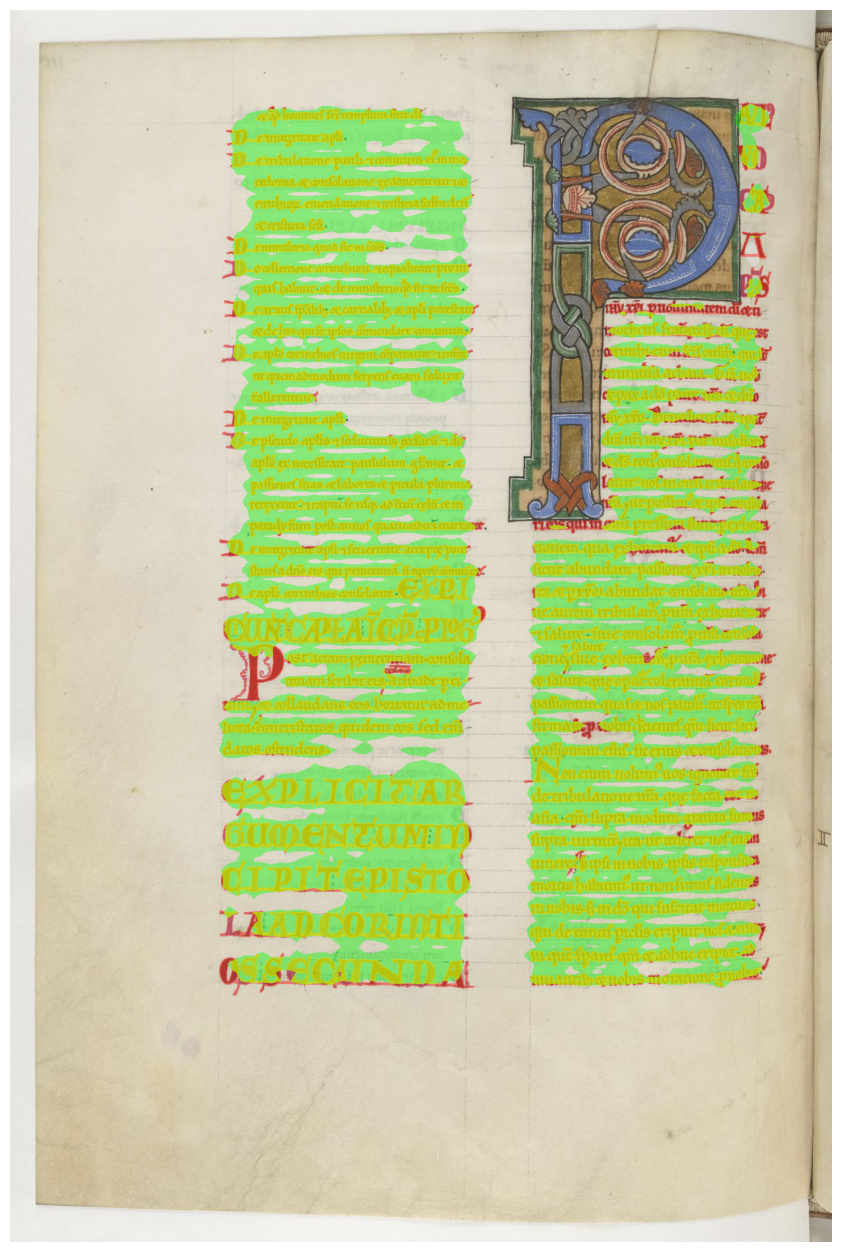

In [21]:
import pandas as pd

summary_path = EVAL_DIR / 'mask_metrics_summary.csv'
metrics_path = EVAL_DIR / 'mask_metrics.csv'
overlay_dir = EVAL_DIR / 'overlays'

assert summary_path.exists(), f'missing summary csv: {summary_path}'
assert metrics_path.exists(), f'missing metrics csv: {metrics_path}'
assert overlay_dir.exists(), f'missing overlay dir: {overlay_dir}'

summary_df = pd.read_csv(summary_path)
metrics_df = pd.read_csv(metrics_path)
display(summary_df)
display(metrics_df.sort_values('IoU').head())

overlay_paths = sorted(overlay_dir.glob('*.png'))
assert overlay_paths, f'no overlays found in {overlay_dir}'
overlay_path = random.choice(overlay_paths)
overlay = cv2.cvtColor(cv2.imread(str(overlay_path)), cv2.COLOR_BGR2RGB)
print('previewing:', overlay_path.name)
plt.figure(figsize=(12, 16))
plt.imshow(overlay)
plt.axis('off')
plt.show()